In [1]:
# =========================
# 1. Import des librairies
# =========================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 300  # Haute résolution pour article
print("Librairies chargées ✅")

Librairies chargées ✅


In [2]:
# =========================
# 2. Chargement des données
# =========================
df = pd.read_csv("household_energy_consumption.csv")

print("Shape :", df.shape)
df.head()

Shape : (90000, 7)


,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [3]:
print("Doublons :", df.duplicated().sum())

Doublons : 0


In [4]:
print("Max consommation :", df["Energy_Consumption_kWh"].max())
print("Nombre de valeurs > 18 :", (df["Energy_Consumption_kWh"] > 18).sum())
df["Energy_Consumption_kWh"] = df["Energy_Consumption_kWh"].clip(upper=18)

Max consommation : 20.0
Nombre de valeurs > 18 : 11422


In [5]:
print("Max consommation :", df["Energy_Consumption_kWh"].max())
print("Nombre de valeurs > 18 :", (df["Energy_Consumption_kWh"] > 18).sum())

Max consommation : 18.0
Nombre de valeurs > 18 : 0


In [6]:
df["Has_AC"] = df["Has_AC"].map({"Yes": 1, "No": 0})

In [7]:


le = LabelEncoder()
df["Household_ID_encoded"] = le.fit_transform(df["Household_ID"])

In [8]:
df = df.sort_values(["Household_ID", "Date"]).reset_index(drop=True)

In [9]:
df_model = df.drop(columns=["Household_ID", "Date"])

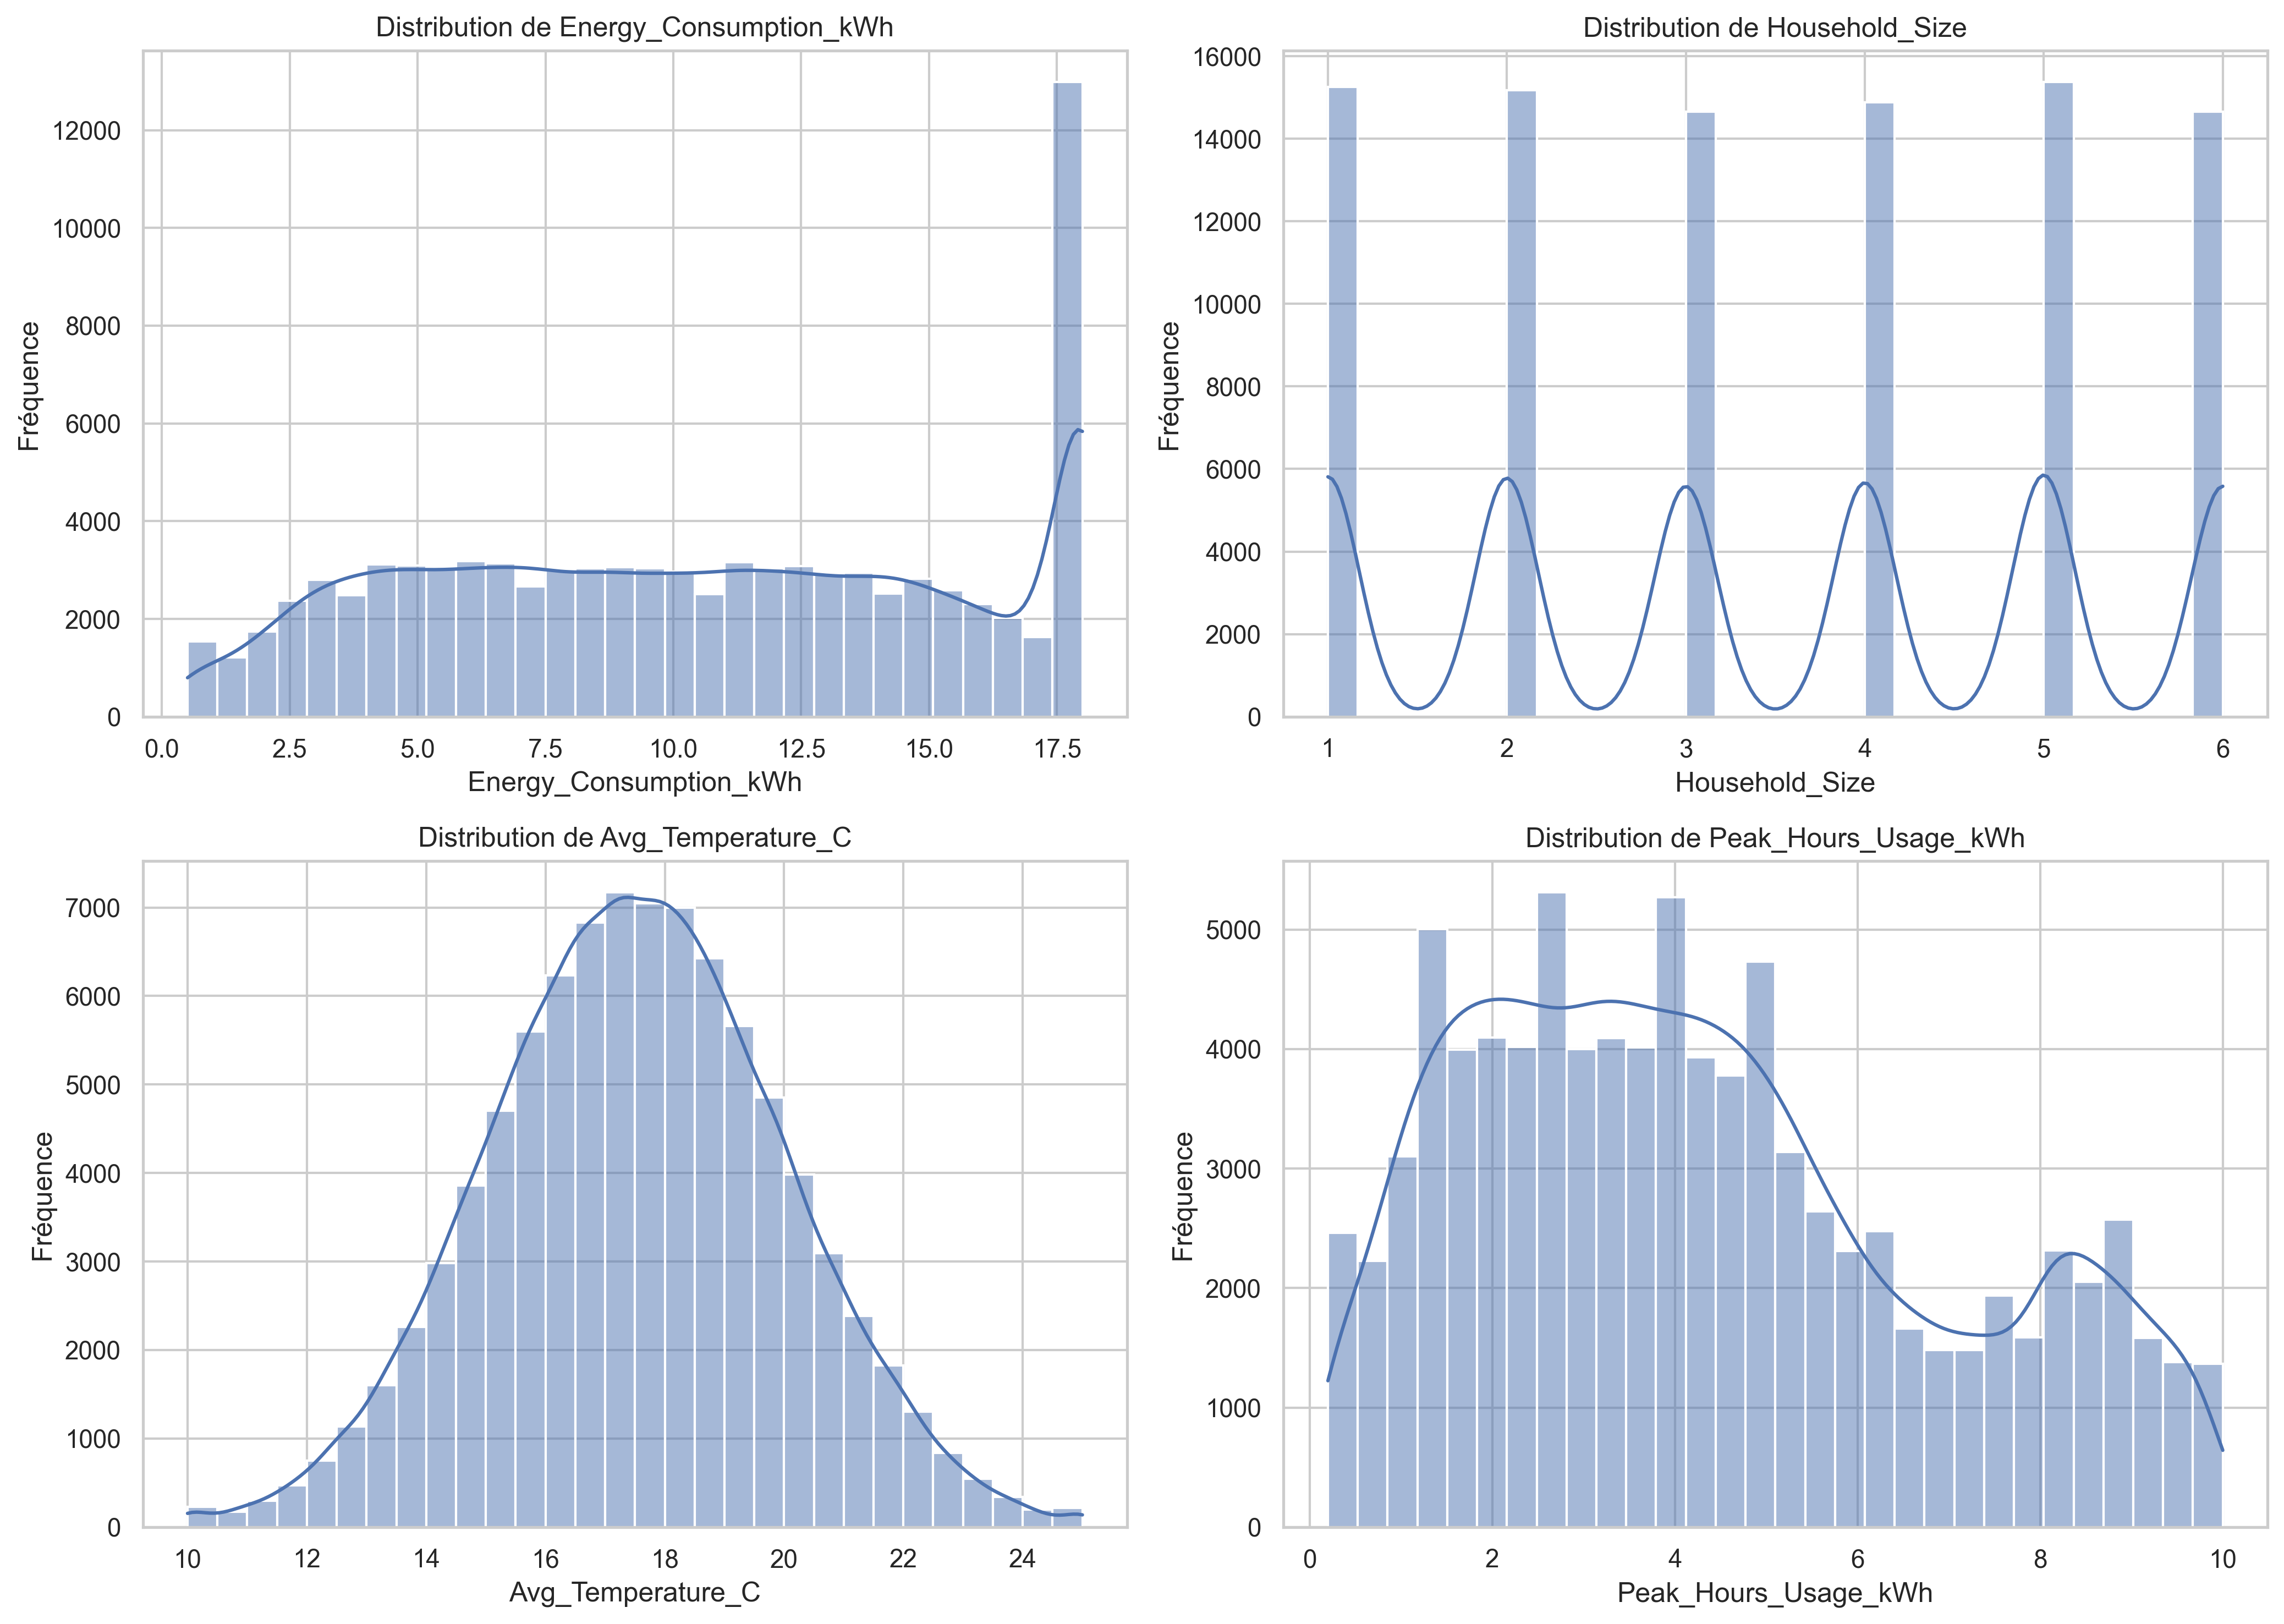

In [10]:


sns.set(style="whitegrid")

num_cols = [
    "Energy_Consumption_kWh",
    "Household_Size",
    "Avg_Temperature_C",
    "Peak_Hours_Usage_kWh"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

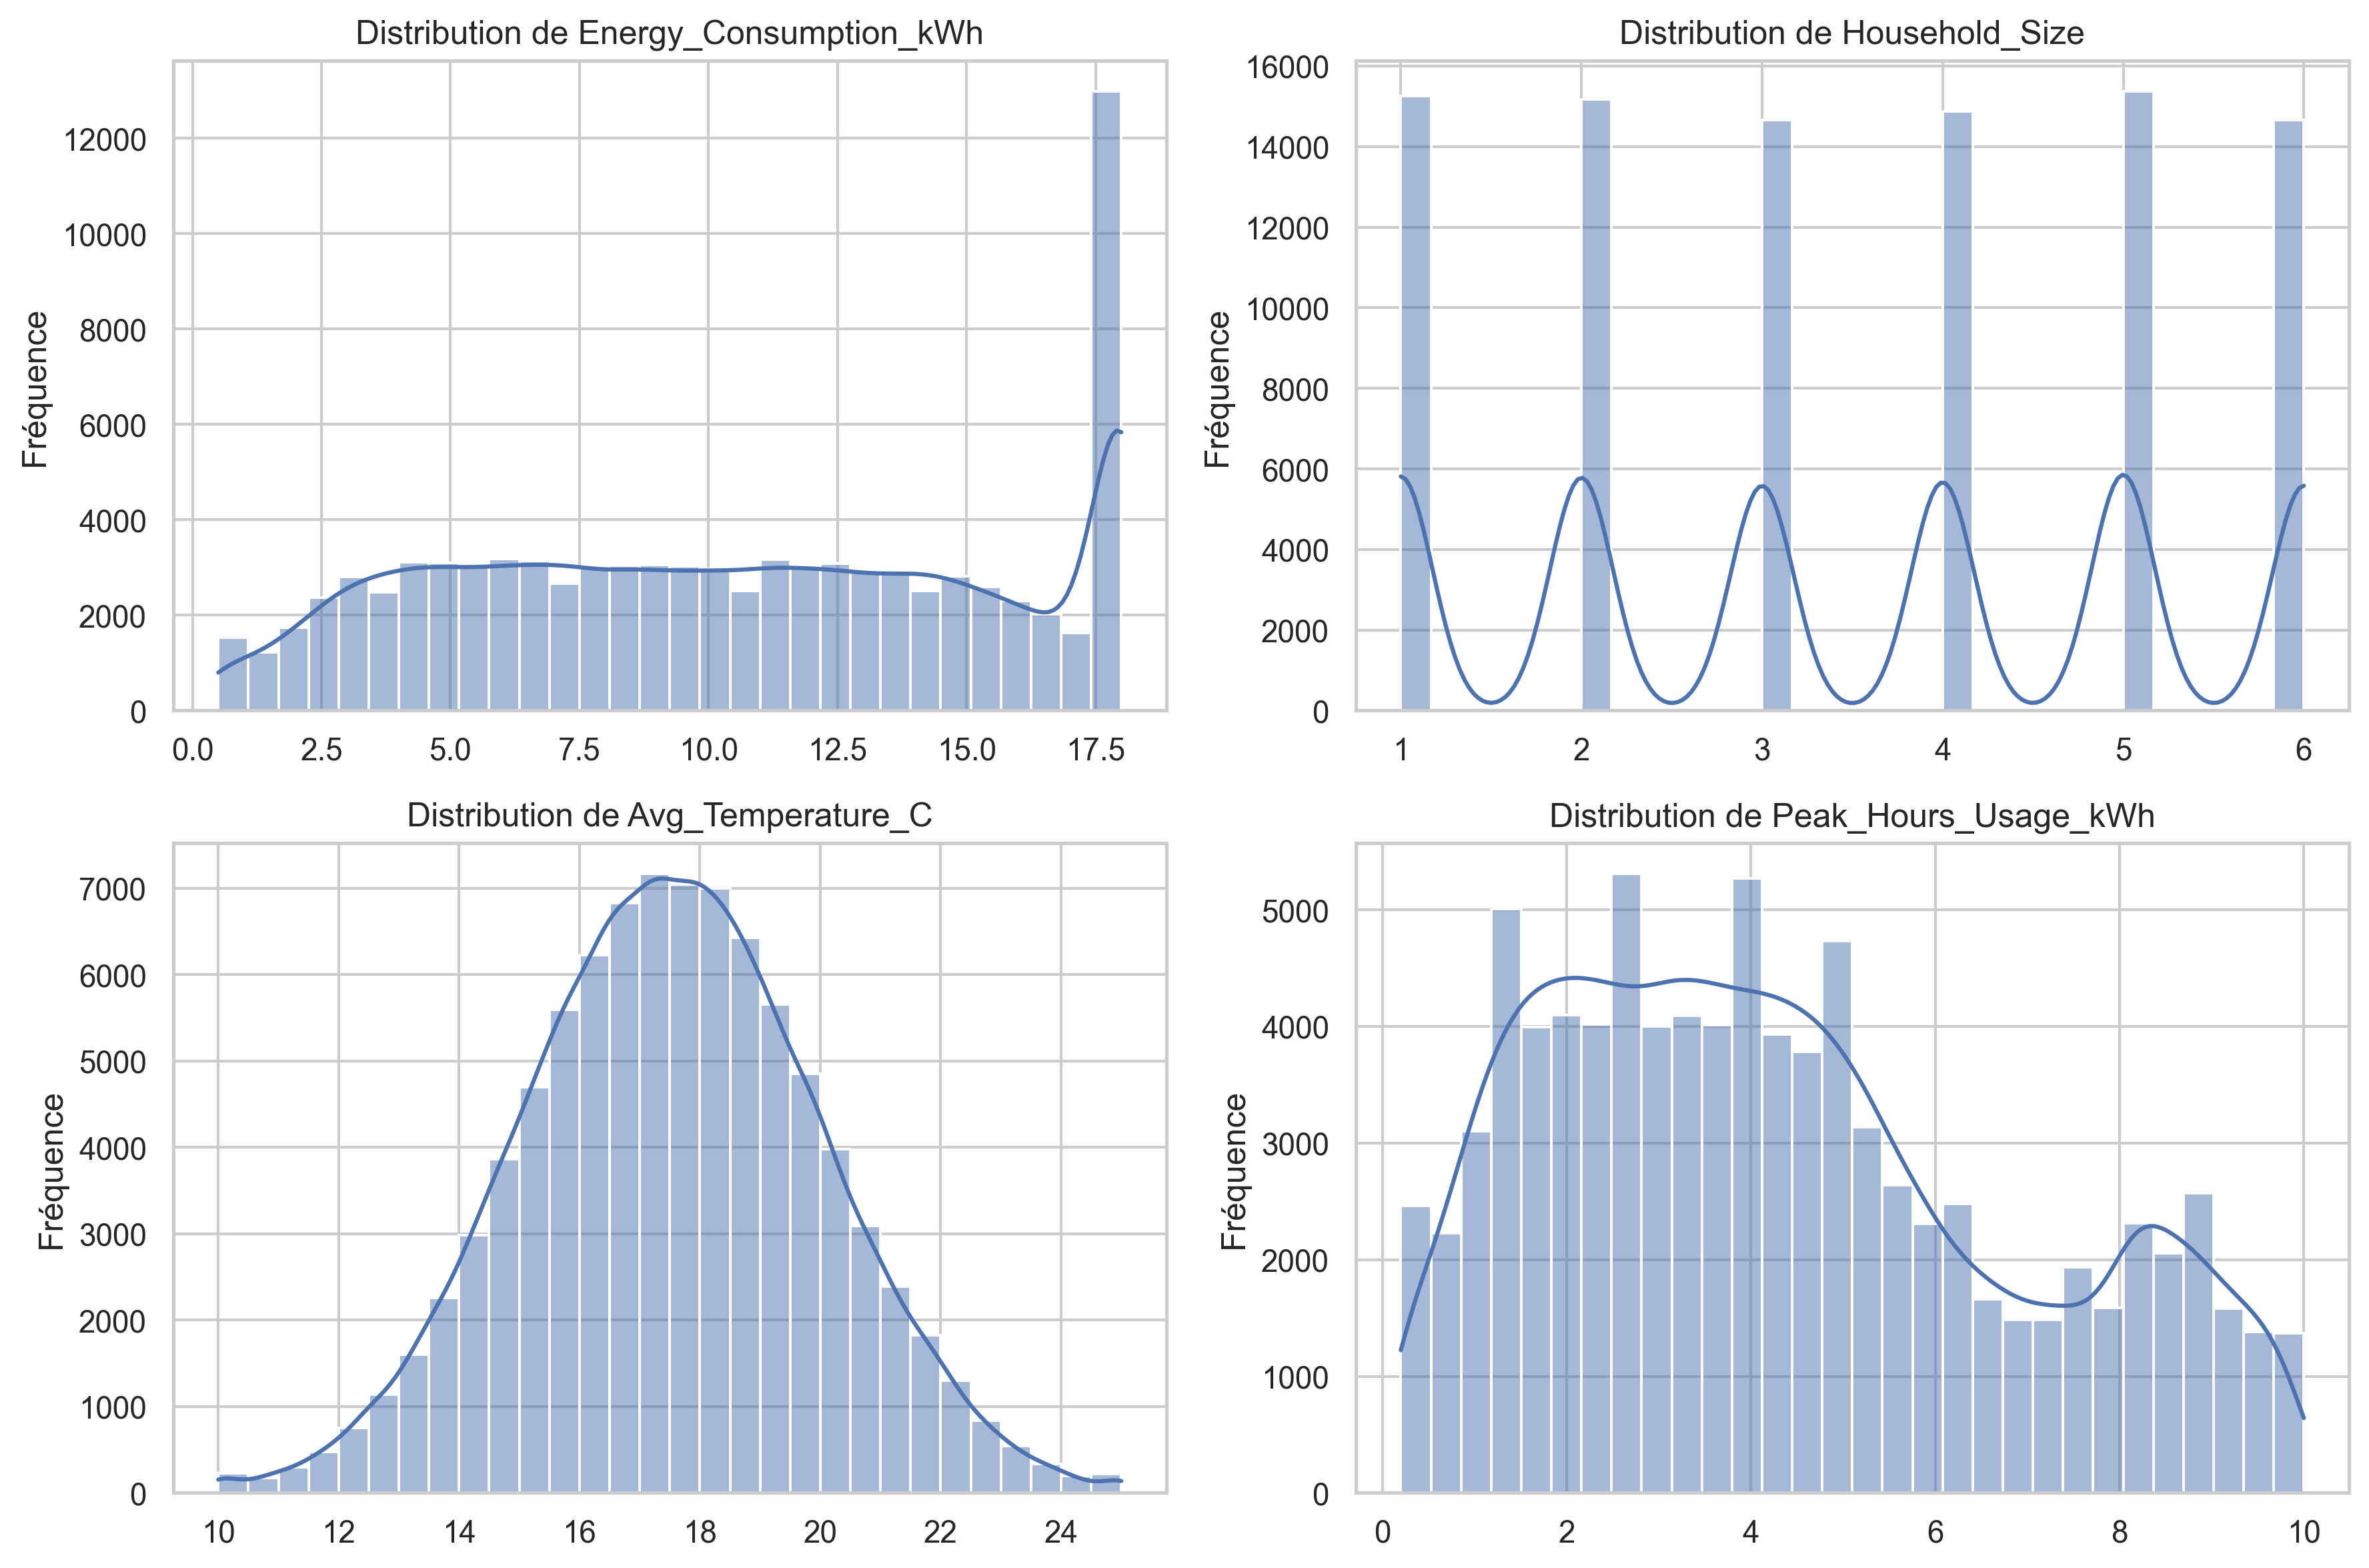

In [11]:
num_cols = [
    "Energy_Consumption_kWh",
    "Household_Size",
    "Avg_Temperature_C",
    "Peak_Hours_Usage_kWh"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df_model[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.savefig("Figure_Distributions.png", dpi=300)
plt.show()

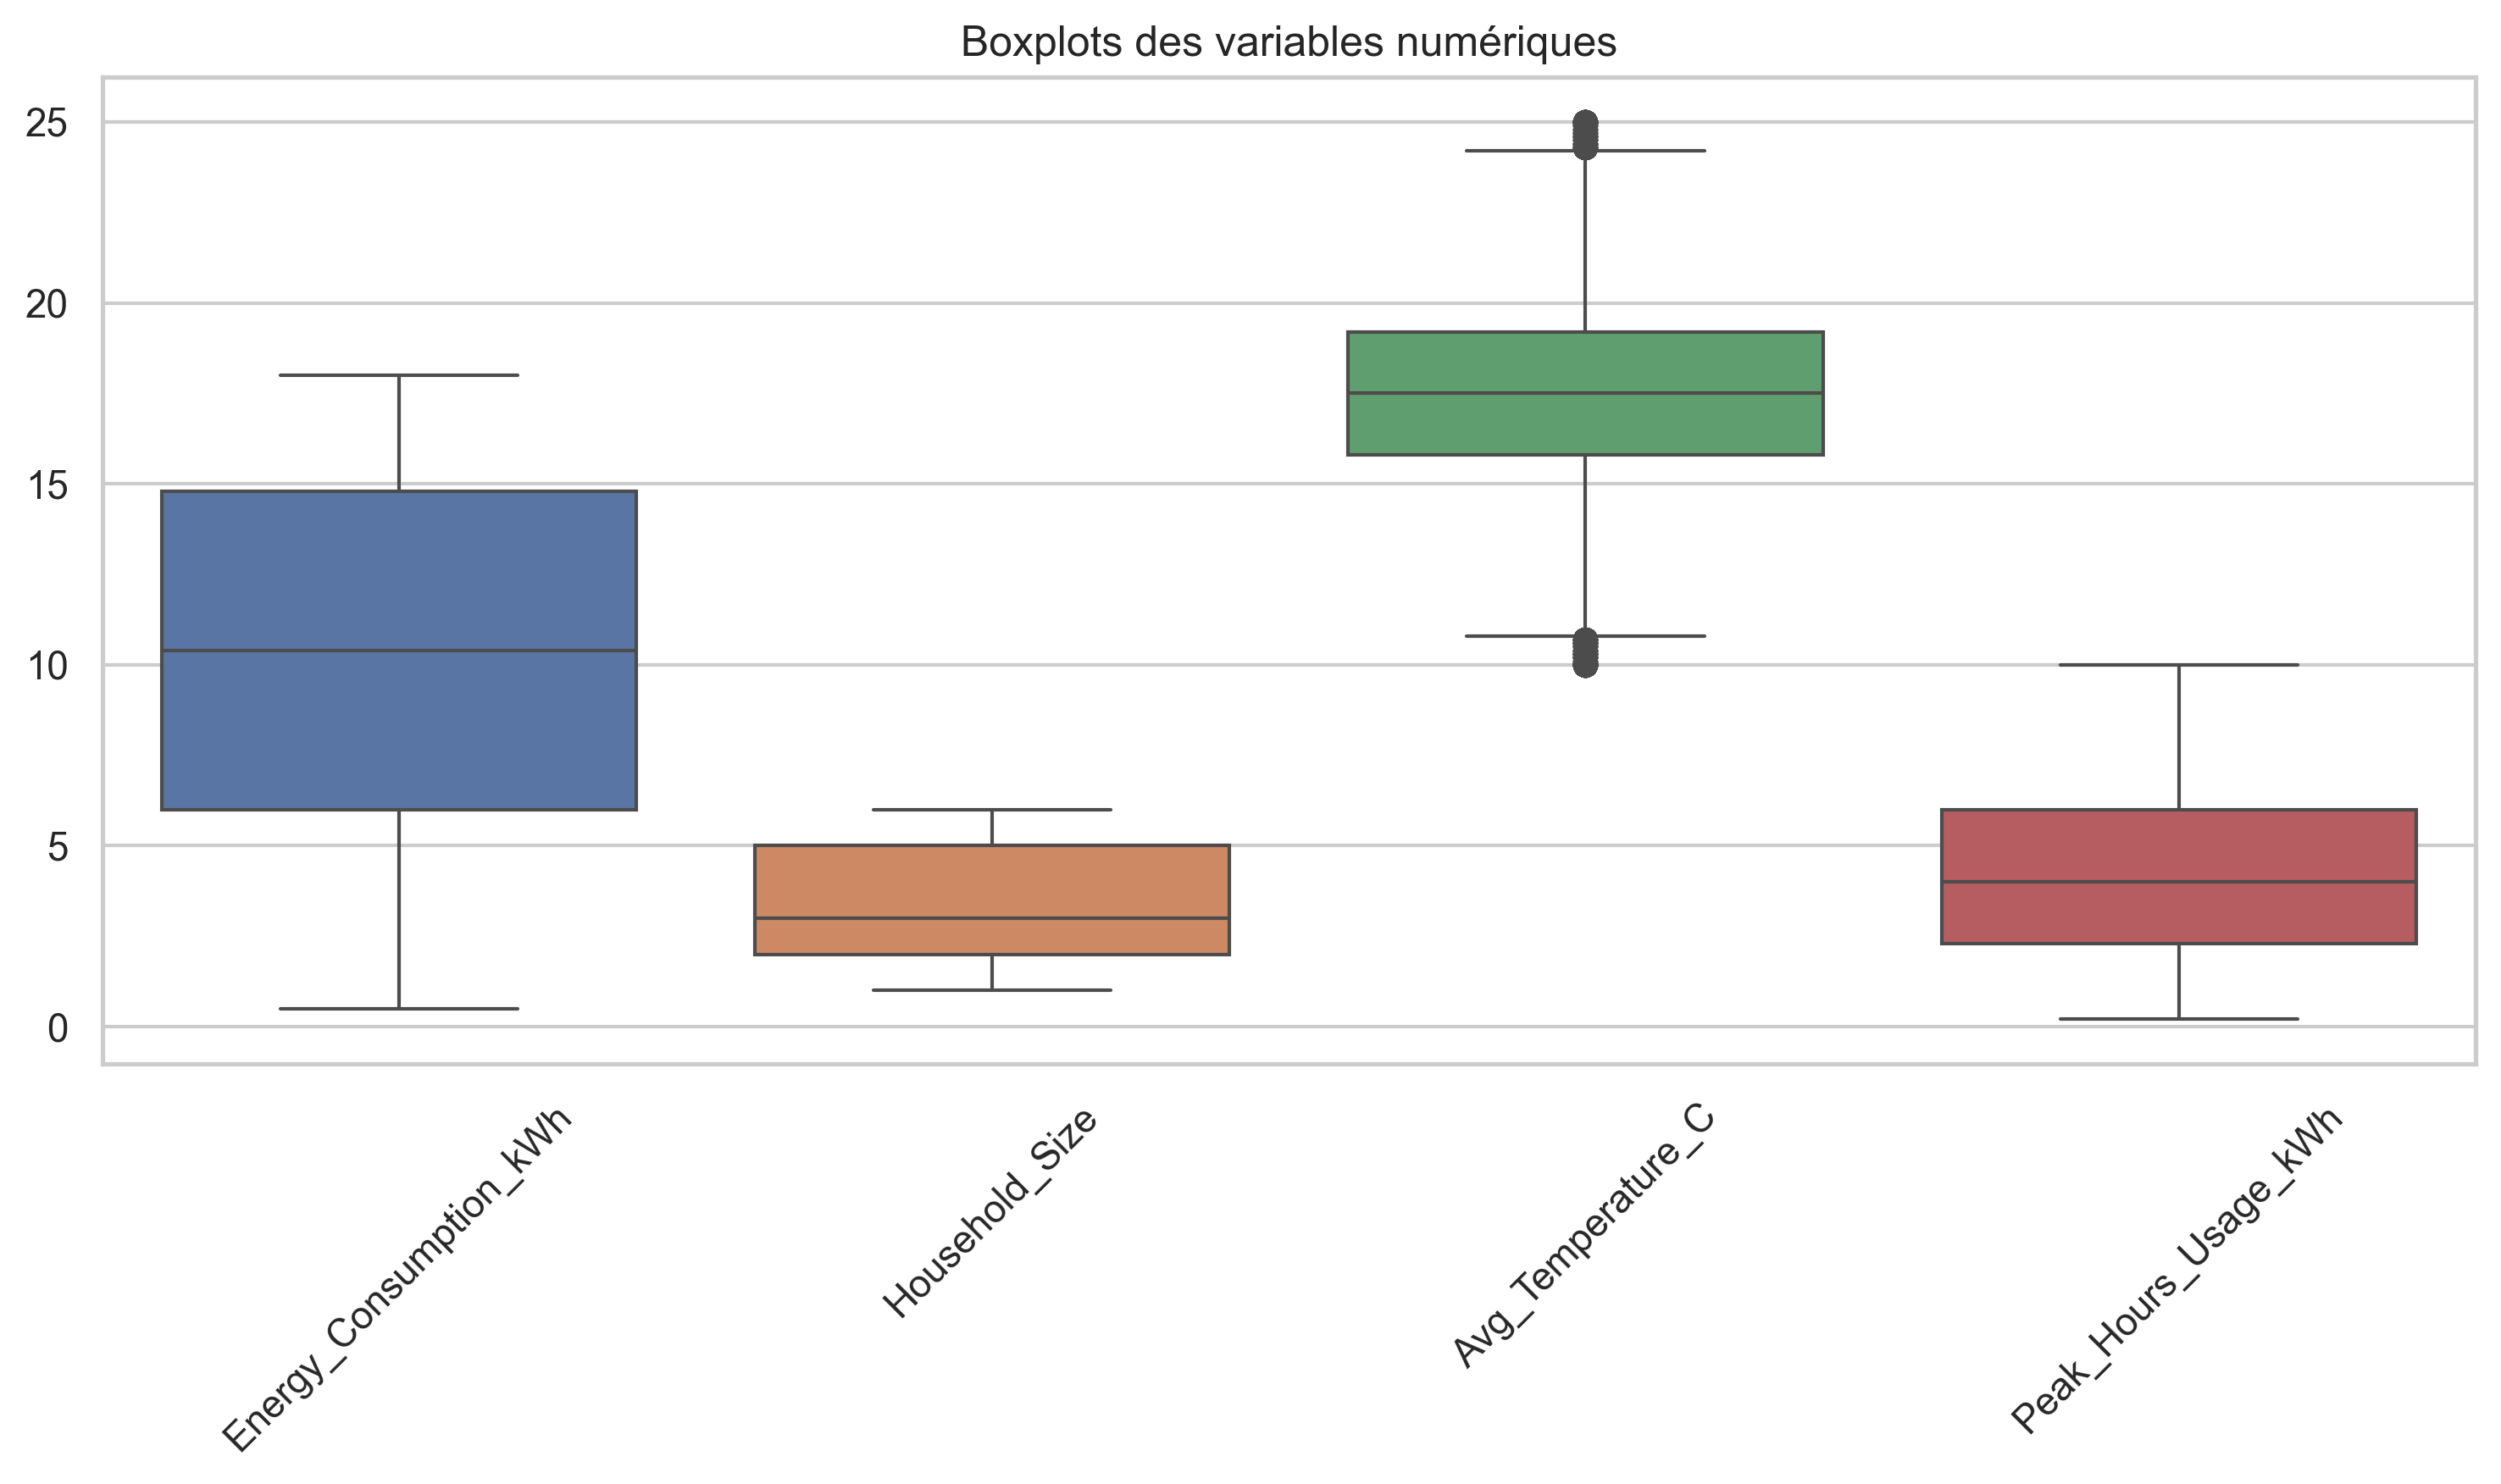

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_model[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots des variables numériques")
plt.tight_layout()
plt.savefig("Figure_Boxplots.png", dpi=300)
plt.show()

In [13]:
plt.figure(figsize=(8, 6))
sns.histplot(df_model["target_next_day"], bins=30, kde=True)
plt.title("Distribution de la consommation cible (J+1)")
plt.xlabel("Consommation (kWh)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.savefig("Figure_Target_Distribution.png", dpi=300)
plt.show()

KeyError: 'target_next_day'

<Figure size 2400x1800 with 0 Axes>

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Avg_Temperature_C",
    y="Energy_Consumption_kWh",
    data=df_model,
    alpha=0.3
)
plt.title("Relation entre Température et Consommation")
plt.tight_layout()
plt.savefig("Figure_Temp_vs_Consumption.png", dpi=300)
plt.show()

In [ ]:
#df_model.to_csv("dataset_clean_ready.csv", index=False)
#print("Dataset prêt ✅")